### Imports and setup

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
from tqdm import tqdm

### Functions

#### Naïve Weyls implementation

In [11]:
def IntegralImageNaive(image_in):
    nx, ny = image_in.shape

    max_value, min_value = 0, 0
    for k in range(1, nx+1):
        for l in range(1, ny+1):
            value = np.sum(image_in[:k, :l])
            if(value > max_value):   max_value = value
            elif(value < min_value): min_value = value
    final_value = max_value - min_value

    return final_value


def WeylsNaive(image_in):
    
    top_left_corner = IntegralImageNaive(image_in)
    top_rght_corner = IntegralImageNaive(np.fliplr(image_in))
    bot_left_corner = IntegralImageNaive(np.flipud(image_in))
    bot_rght_corner = IntegralImageNaive(np.fliplr(np.flipud(image_in)))

    return np.max([top_left_corner, top_rght_corner, bot_left_corner, bot_rght_corner])


#### Paper's Weyls implementation

In [12]:
def IntegralImageOptimized(image_in):
    rows, cols = image_in.shape
    integral_image = np.zeros((rows, cols))

    # First cell
    integral_image[0, 0] = image_in[0, 0]

    # First column
    for x in range(1, rows):
        integral_image[x, 0] = integral_image[x-1, 0] + image_in[x, 0]

    # Others cells
    for y in range(1, cols):
        accumulator = image_in[0, y]
        integral_image[0, y] = integral_image[0, y-1] + accumulator
        for x in range(1, rows):
            accumulator += image_in[x, y]
            integral_image[x, y] = integral_image[x, y-1] + accumulator
    
    return integral_image


def WeylsOptimized(image_in):

    rows, cols = image_in.shape
    integral_images = np.zeros((4, rows, cols))
    integral_images[0] = IntegralImageOptimized(image_in)

    for x in range(rows):
        for y in range(cols):
            integral_images[1][x, y] = integral_images[0][x, cols-1] - integral_images[0][x, y]
            integral_images[2][x, y] = integral_images[0][rows-1, y] - integral_images[0][x, y]
            integral_images[3][x, y] = integral_images[0][rows-1, cols-1] + integral_images[0][x, y] - integral_images[0][rows-1, y] - integral_images[0][x, cols-1]

    # Correcting specific cases
    integral_images[1][:, cols-1] = integral_images[0][:, cols-1]                                           # Π3 : if y = H
    integral_images[2][rows-1, :] = integral_images[0][rows-1, :]                                           # Π3 : if y = H
    integral_images[3][rows-1, :-1] = integral_images[0][rows-1, cols-1] - integral_images[0][rows-1, :-1]  # Π4 : if x = W, y != H
    integral_images[3][:-1, cols-1] = integral_images[0][rows-1, cols-1] - integral_images[0][:-1, cols-1]  # Π4 : if x != W, y = H
    integral_images[3][rows-1, cols-1] = integral_images[0][rows-1, cols-1]                                 # Π4 : if x = W, y = H

    minimums = np.minimum(0, np.min(integral_images, axis=(1, 2)))
    maximums = np.maximum(0, np.max(integral_images, axis=(1, 2)))
    
    return np.max(maximums - minimums)

#### Matching pattern function

In [ ]:
def WeylsMatching(pattern, image_in, WeylsFunction=WeylsOptimized, display_execution_time=True):
    nx, ny = image_in.shape
    px, py = pattern.shape
    padx, pady = px // 2, py // 2

    # Execution time section
    start_time = time.time()
    
    image_w_borders = cv2.copyMakeBorder(image_in, pady, pady, padx, padx, cv2.BORDER_CONSTANT, value=0.0)
    image_out = np.zeros((nx, ny))
    
    for i in tqdm(range(nx)):
        for j in range(ny):
            zone = image_w_borders[i:i+px, j:j+py]
            diff = zone - pattern
            image_out[i, j] = WeylsFunction(diff)


    if(display_execution_time):
        total_time = time.time() - start_time
        print("------------------------------------------------------------------")
        print(f"Total execution time        : {total_time} seconds")
        print(f"Average row execution time  : {total_time / nx} seconds")
        print(f"Average cell execution time : {total_time / (nx * ny)} seconds")
        print("------------------------------------------------------------------")
    
    return image_out
    

### Base code

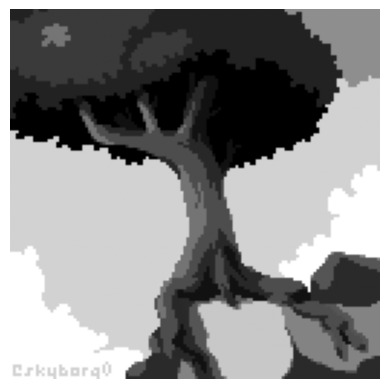

In [14]:
base_image = cv2.imread('datasets/tests_images/tree.png', cv2.IMREAD_GRAYSCALE) / 255.0
base_image = cv2.resize(base_image, dsize=(128, 128), interpolation=cv2.INTER_CUBIC)
plt.axis('off')
plt.imshow(base_image, cmap='gray')
plt.show()

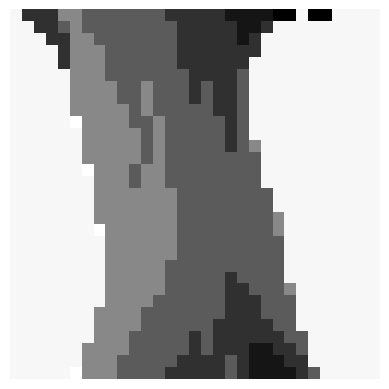

In [15]:
part_image = base_image[54:85, 54:85]
plt.axis('off')
plt.imshow(part_image, cmap='gray')
plt.show()

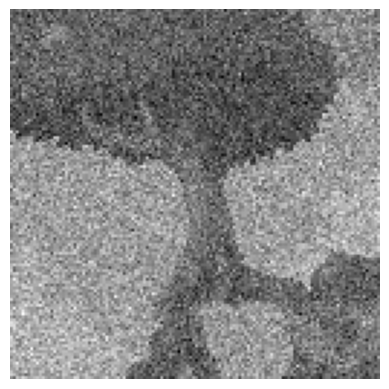

In [16]:
np.random.seed(42)
noised_image = np.random.normal(base_image, 0.2)
plt.axis('off')
plt.imshow(noised_image, cmap='gray')
plt.show()

In [ ]:
diff_image_optimized = WeylsMatching(part_image, noised_image, WeylsOptimized)
plt.axis('off')
plt.imshow(diff_image_optimized, cmap='gray')
plt.show()

 23%|██▎       | 29/128 [00:13<00:48,  2.06it/s]

In [ ]:
diff_image_naive = WeylsMatching(part_image, noised_image, WeylsNaive)
plt.axis('off')
plt.imshow(diff_image_naive, cmap='gray')
plt.show()

 15%|█▍        | 19/128 [00:45<04:18,  2.37s/it]


KeyboardInterrupt: 

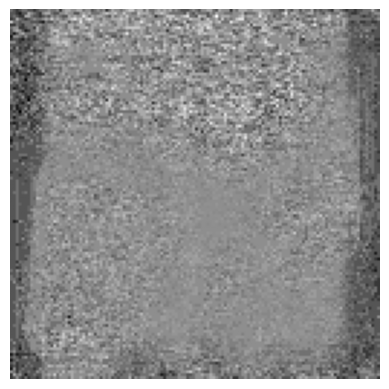

[[-5.68434189e-14 -1.13686838e-13 -1.70530257e-13 ...  5.68434189e-14
  -5.68434189e-14 -1.13686838e-13]
 [-1.13686838e-13 -1.13686838e-13 -1.70530257e-13 ... -5.68434189e-14
   0.00000000e+00  0.00000000e+00]
 [-1.13686838e-13 -5.68434189e-14 -1.13686838e-13 ... -5.68434189e-14
  -1.13686838e-13 -5.68434189e-14]
 ...
 [ 0.00000000e+00 -5.68434189e-14 -1.70530257e-13 ... -5.68434189e-14
  -1.13686838e-13 -5.68434189e-14]
 [-1.70530257e-13  5.68434189e-14 -5.68434189e-14 ...  0.00000000e+00
  -5.68434189e-14  0.00000000e+00]
 [-1.70530257e-13 -1.13686838e-13  0.00000000e+00 ... -5.68434189e-14
  -5.68434189e-14 -1.70530257e-13]]


In [ ]:
models_variation = diff_image_naive - diff_image_optimized
plt.axis('off')
plt.imshow(models_variation, cmap='gray')
plt.show()

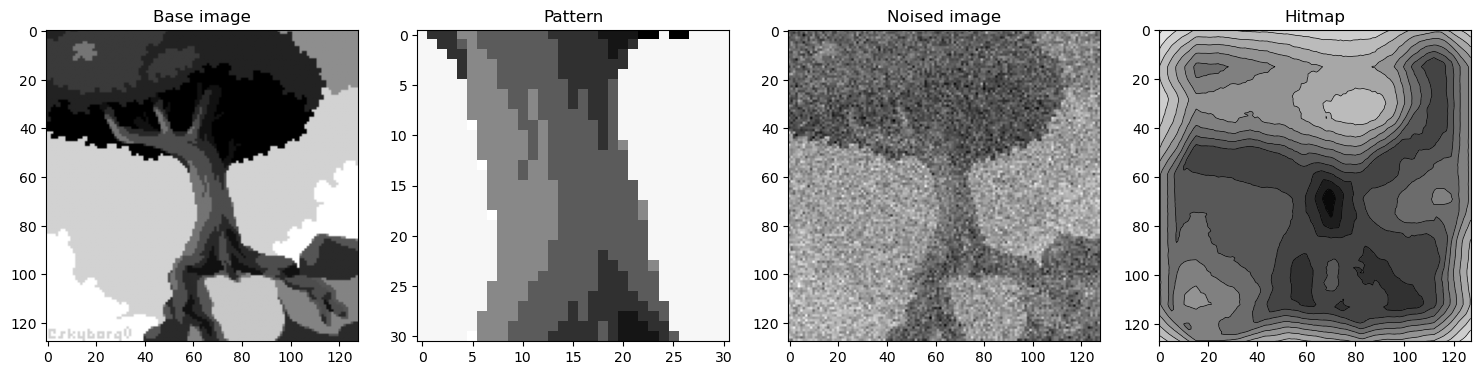

In [ ]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 15))

ax1.imshow(base_image, cmap='gray')
ax1.set_title("Base image")

ax2.imshow(part_image, cmap='gray')
ax2.set_title("Pattern")

ax3.imshow(noised_image, cmap='gray')
ax3.set_title("Noised image")

ax4.contourf(diff_image_optimized, levels=12, cmap='gray')
ax4.contour(diff_image_optimized, levels=12, colors='black', linewidths=0.5)
ax4.set_aspect('equal')
ax4.invert_yaxis()
ax4.set_title("Hitmap")

plt.tight_layout()
plt.show()

In [ ]:
position_found = np.unravel_index(diff_image.argmin(), diff_image.shape)
print(f"Found at position : {position_found}")

Found at position : (np.int64(69), np.int64(69))


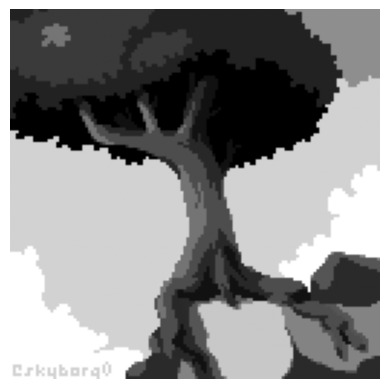

In [ ]:
new_image = base_image.copy()
new_image[54:85, 54:85] = 0.0

px, py = position_found
new_image[px - 15:px + 15 + 1, py - 15:py + 15 + 1] = part_image
plt.axis('off')
plt.imshow(new_image, cmap='gray')
plt.show()

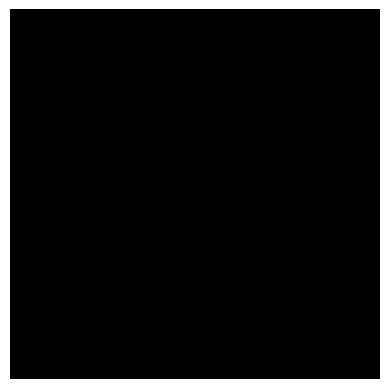

In [ ]:
final_diff_image = base_image - new_image
plt.axis('off')
plt.imshow(final_diff_image, cmap='gray')
plt.show()